In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [22]:
df = pd.read_csv("AmazonSales.csv")
print(df.head())

   Unnamed: 0    Acs  Refrigerators  Microwaves  WashingMachines  Smartphones  \
0           1  230.1           37.8        69.2             69.2         69.2   
1           2   44.5           39.3        45.1             45.1         45.1   
2           3   17.2           45.9        69.3             69.3         69.3   
3           4  151.5           41.3        58.5             58.5         58.5   
4           5  180.8           10.8        58.4             58.4         58.4   

   Laptops  Sales  
0     69.2   22.1  
1     45.1   10.4  
2     69.3    9.3  
3     58.5   18.5  
4     58.4   12.9  


In [23]:
df.columns

Index(['Unnamed: 0', 'Acs', 'Refrigerators', 'Microwaves', 'WashingMachines',
       'Smartphones', 'Laptops', 'Sales'],
      dtype='object')

In [24]:
df = df.drop(columns=['Unnamed: 0'])

In [25]:
df.describe()

,Acs,Refrigerators,Microwaves,WashingMachines,Smartphones,Laptops,Sales
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,489.152682,373.188314,350.646935,350.646935,350.646935,350.646935,356.619732
std,277.828085,277.696245,269.127816,269.127816,269.127816,269.127816,275.459711
min,0.700000,0.000000,0.300000,0.300000,0.300000,0.300000,1.600000
25%,239.875000,95.350000,73.850000,73.850000,73.850000,73.850000,77.050000
50%,470.200000,356.100000,326.500000,326.500000,326.500000,326.500000,337.800000
75%,730.950000,616.850000,587.250000,587.250000,587.250000,587.250000,598.550000
max,991.700000,877.600000,848.000000,848.000000,848.000000,848.000000,859.300000


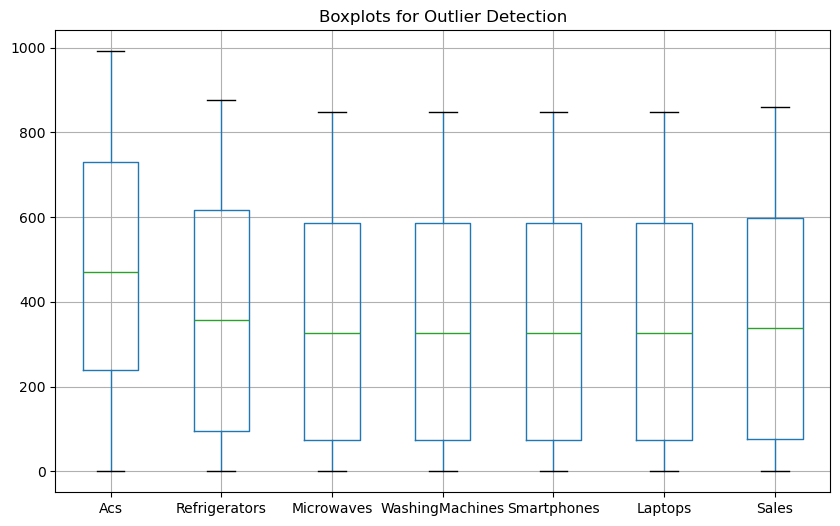

In [27]:
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title("Boxplots for Outlier Detection")
plt.show()

In [11]:
df.isnull().sum()

Acs                0
Refrigerators      0
Microwaves         0
WashingMachines    0
Smartphones        0
Laptops            0
Sales              0
dtype: int64

In [12]:
X = df[['Acs', 'Refrigerators', 'Microwaves', 'WashingMachines', 'Smartphones', 'Laptops']]
y = df['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [20]:
results_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(results_df)

     Actual Sales  Predicted Sales
0           787.3       786.977079
1            96.3        96.770606
2           352.3       352.476622
3           640.3       640.145890
4           460.3       460.352598
..            ...              ...
204         505.3       505.300921
205         664.3       664.118329
206         433.3       433.383604
207         274.3       274.566195
208         820.3       819.939183

[209 rows x 2 columns]


In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Mean Squared Error: 22.536438924177332
Root Mean Squared Error: 4.747255936241202
R² Score: 0.9997065443618115
Intercept: -18.348290600889754
Coefficients: [0.06025335 0.72831424 0.05257101 0.05257101 0.05257101 0.05257101]


In [21]:
features = ['Acs', 'Refrigerators', 'Microwaves', 'WashingMachines', 'Smartphones', 'Laptops']
inputs = {feature: [float(input(f"Enter advertising spend on {feature}: "))] for feature in features}
custom_data = pd.DataFrame(inputs)

predicted_sales = model.predict(custom_data)
print(f"Predicted Sales: {predicted_sales[0]:.2f}")

Enter advertising spend on Acs:  475
Enter advertising spend on Refrigerators:  370
Enter advertising spend on Microwaves:  340
Enter advertising spend on WashingMachines:  333
Enter advertising spend on Smartphones:  348
Enter advertising spend on Laptops:  325


Predicted Sales: 350.51


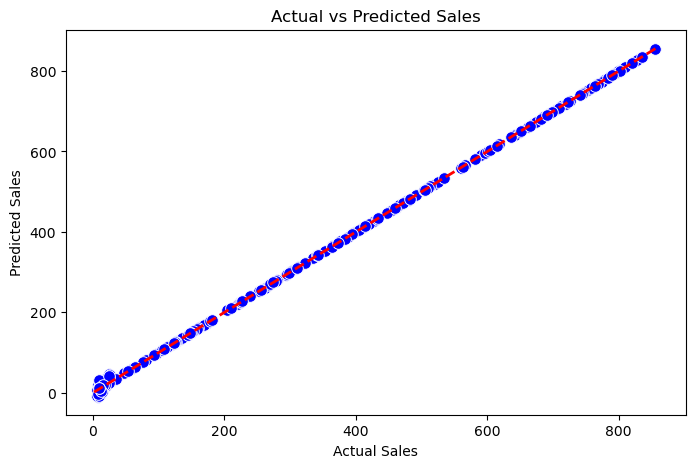

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, color='blue', s=70)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

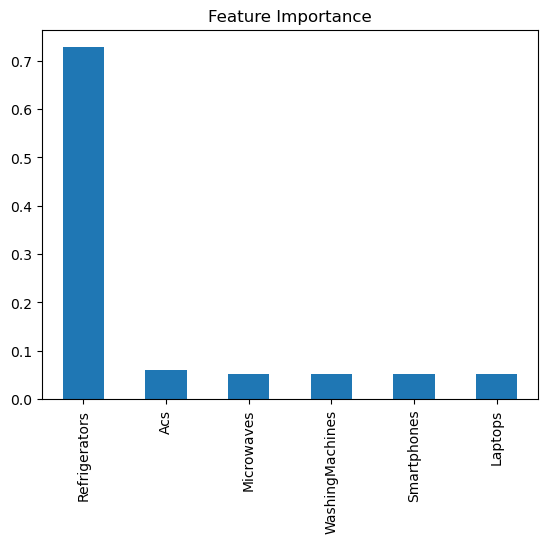

In [19]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df.sort_values(by='Coefficient', ascending=False).plot(kind='bar', legend=False)
plt.title('Feature Importance')
plt.show()